# ReLoG - different seed
In questa versione si esegue il modello con diversi seed, per ottenere media e varianza.

In [1]:
# IMPORT

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import copy
import random
import math

In [2]:
# =============================================================================
# SEED
# =============================================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    # [OPT-9] benchmark=True accelera operazioni su tensori di dimensione fissa
    # (le torri hanno sempre input_dim=384, quindi CUDA può ottimizzare i kernel)
    torch.backends.cudnn.benchmark = True


In [4]:
# =============================================================================
# DATI
# =============================================================================

device = 'cuda' if torch.cuda.is_available() else 'cpu'

df_sampled      = pd.read_parquet('../../preprocessing/CD_Vinyl_review.parquet')
df_meta_aligned = pd.read_parquet('../../preprocessing/CD_Vinyl_meta.parquet')

NUM_USERS    = df_sampled['user_id_int'].nunique()
NUM_ITEMS    = df_sampled['item_id_int'].nunique()
INTERACTIONS = len(df_sampled)
SPARSITY     = (1 - (INTERACTIONS / (NUM_USERS * NUM_ITEMS))) * 100

print(f"Utenti: {NUM_USERS}, Item: {NUM_ITEMS}, Interactions: {INTERACTIONS}")
print(f"Sparsity: {SPARSITY:.2f}%")

Utenti: 3905, Item: 27149, Interactions: 49659
Sparsity: 99.95%


## Calcolo embedding

In [5]:
# =============================================================================
# EMBEDDINGS SBERT
# =============================================================================

sbert = SentenceTransformer('all-MiniLM-L6-v2', device=device)

df_sampled['summary']    = df_sampled['summary'].fillna('')
df_sampled['reviewText'] = df_sampled['reviewText'].fillna('')
df_sampled['full_text']  = df_sampled['summary'] + ". " + df_sampled['reviewText']

print("Calcolo embeddings review...")
review_embeddings = sbert.encode(
    df_sampled['full_text'].tolist(),
    batch_size=64, show_progress_bar=True, convert_to_numpy=True
)
review_emb_map = {i: review_embeddings[i] for i in range(len(df_sampled))}

print("Calcolo embeddings metadati item...")
meta_embeddings = sbert.encode(
    df_meta_aligned['meta_text'].tolist(),
    batch_size=64, show_progress_bar=True, convert_to_numpy=True
)
item_meta_tensor = torch.tensor(meta_embeddings, dtype=torch.float32)
print(f"Item bank: {item_meta_tensor.shape}")

# [OPT-1] Pre-carica item_meta_tensor su GPU UNA VOLTA SOLA qui.
# Nel codice originale veniva fatto .to(device) dentro ogni chiamata a
# train_client e evaluate_top_k, causando trasferimenti CPU->GPU ripetuti
# (potenzialmente centinaia per round). Con una sola GPU, questo è un
# bottleneck misurabile specialmente su item bank grandi.
item_meta_tensor_gpu = item_meta_tensor.to(device)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calcolo embeddings review...


Batches:   0%|          | 0/776 [00:00<?, ?it/s]

Calcolo embeddings metadati item...


Batches:   0%|          | 0/425 [00:00<?, ?it/s]

Item bank: torch.Size([27149, 384])


##  Definizione architettura

In [20]:
# =============================================================================
# ARCHITETTURA
# =============================================================================

class UserTower(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=512, output_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.1),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class ItemTower(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=512, output_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.1),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, text_emb):
        return F.normalize(self.net(text_emb), dim=-1)

class TwoTowerRecommender(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=512, output_dim=256, inference_temperature=0.07):
        super().__init__()
        self.item_tower = ItemTower(input_dim, hidden_dim, output_dim)
        self.user_tower = UserTower(input_dim, hidden_dim, output_dim)
        self.inference_temperature = inference_temperature

    def get_user_repr(self, review_embeddings):
        return self.user_tower(review_embeddings).mean(dim=0, keepdim=True)

    def get_item_repr(self, item_meta_embeddings):
        return self.item_tower(item_meta_embeddings)

    def training_score(self, user_repr, item_reprs):
        raw_scores = (user_repr * item_reprs).sum(dim=-1) # dot product
        return raw_scores / self.inference_temperature

    def score(self, user_repr, item_reprs):
        return self.training_score(user_repr, item_reprs)


def bpr_loss(pos_scores, neg_scores):
    # [OPT-5] BPR loss originale usava repeat_interleave + broadcasting implicito
    # che creava tensori intermedi grandi inutilmente.
    # Questa versione usa unsqueeze+broadcasting diretto: più compatta e più veloce.
    # pos_scores: [N_pos], neg_scores: [N_neg]
    # diff: [N_pos, N_neg] via broadcasting — nessuna allocazione extra
    diff = pos_scores.unsqueeze(1) - neg_scores.unsqueeze(0)
    return -F.logsigmoid(diff).mean()

# Utility dati

In [21]:
def get_client_data(user_id, df, emb_map, mode="train"):
    user_df = df[df['user_id_int'] == user_id].sort_values('timestamp')
    if len(user_df) < 3:
        return None, None
    indices = user_df.index.tolist()
    train_idx = indices[:-2]
    val_idx   = indices[-2]
    test_idx  = indices[-1]
    X_train = torch.tensor(
        np.array([emb_map[i] for i in train_idx]),
        dtype=torch.float32
    )
    train_item_ids = user_df.loc[train_idx, 'item_id_int'].tolist()
    if mode == "val":
        target_id = int(user_df.loc[val_idx, 'item_id_int'])
    elif mode == "test":
        target_id = int(user_df.loc[test_idx, 'item_id_int'])
    else:
        target_id = None
    return (X_train, train_item_ids), target_id

In [22]:
# =============================================================================
# HARD NEGATIVE SAMPLING — OTTIMIZZATO
# =============================================================================

def sample_hard_negatives(user_repr, pos_set, all_metas, local_model,
                          num_neg, num_candidates, device, num_total_items):
    # [OPT-3] Il loop originale campionava con random.randint() uno alla volta
    # dentro un while, con controllo Python ad ogni iterazione (lento).
    # np.random.choice con replace=False campiona tutti i candidati in un colpo
    # solo, completamente in C, poi filtra con una maschera booleana vettorizzata.
    # Su num_candidates=500 questo è ~10-20x più veloce del loop Python.
    all_ids = np.arange(num_total_items)
    pos_arr = np.array(list(pos_set), dtype=np.int64)
    mask = np.ones(num_total_items, dtype=bool)
    mask[pos_arr] = False
    eligible = all_ids[mask]

    if len(eligible) < num_neg:
        return eligible.tolist()

    n_cands = min(num_candidates, len(eligible))
    candidate_ids = np.random.choice(eligible, size=n_cands, replace=False)

    with torch.no_grad():
        cand_ids_tensor = torch.tensor(candidate_ids, device=device)
        cand_metas = all_metas[cand_ids_tensor]
        cand_reprs = local_model.get_item_repr(cand_metas)
        cand_scores = local_model.training_score(user_repr.detach(), cand_reprs)

    top_k = min(num_neg, len(candidate_ids))
    top_indices = torch.topk(cand_scores, top_k).indices.cpu().numpy()
    return candidate_ids[top_indices].tolist()

## Train client

In [30]:
def get_lr(base_lr, current_step, warmup_steps, total_steps):
    """LR warmup lineare → cosine annealing."""
    if current_step < warmup_steps:
        return base_lr * (current_step + 1) / warmup_steps
    progress = (current_step - warmup_steps) / max(1, total_steps - warmup_steps)
    return base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))

def train_client(user_id, global_state_dict, X_train_reviews, train_item_ids,
                 all_metas_gpu,   # [OPT-1] riceve direttamente il tensore già su GPU
                 device,
                 lr=0.001, epochs=5, num_neg=10, use_hard_negatives=True,
                 lr_warmup_steps=10, current_step=0, total_steps=100):

    local_model = TwoTowerRecommender().to(device)
    local_model.load_state_dict(global_state_dict, strict=False)

    effective_lr = get_lr(lr, current_step, lr_warmup_steps, total_steps)
    optimizer = torch.optim.Adam(local_model.parameters(), lr=effective_lr)
    local_model.train()

    # [OPT-1] all_metas è già su GPU — nessun trasferimento qui
    X_train = X_train_reviews.to(device)
    pos_set = set(train_item_ids)
    num_total_items = all_metas_gpu.shape[0]

    # [OPT-4] pos_tensor costruito UNA VOLTA fuori dal loop delle epoche.
    # Nel codice originale veniva ricostruito a ogni epoca (allocazione GPU inutile).
    pos_tensor = torch.tensor(train_item_ids, device=device)
    pos_metas  = all_metas_gpu[pos_tensor]   # shape: [N_pos, 384] — fisso per tutte le epoche

    loss = None
    for _ in range(epochs):
        optimizer.zero_grad()
        user_repr = local_model.get_user_repr(X_train)

        # pos_metas è già pronto — solo forward pass
        pos_reprs = local_model.get_item_repr(pos_metas)

        if use_hard_negatives:
            neg_ids = sample_hard_negatives(
                user_repr, pos_set, all_metas_gpu, local_model,
                num_neg=len(train_item_ids) * num_neg,
                num_candidates=2000, device=device,
                num_total_items=num_total_items
            )
        else:
            # [OPT-3] anche il campionamento random semplice vettorizzato
            all_ids = np.arange(num_total_items)
            mask = np.ones(num_total_items, dtype=bool)
            mask[np.array(list(pos_set))] = False
            neg_ids = np.random.choice(
                all_ids[mask],
                size=len(train_item_ids) * num_neg,
                replace=True
            ).tolist()

        neg_tensor = torch.tensor(neg_ids, device=device)
        neg_metas  = all_metas_gpu[neg_tensor]
        neg_reprs  = local_model.get_item_repr(neg_metas)

        pos_scores = local_model.training_score(user_repr, pos_reprs)
        neg_scores = local_model.training_score(user_repr, neg_reprs)

        # [OPT-5] BPR loss con broadcasting diretto (vedi definizione sopra)
        loss = bpr_loss(pos_scores, neg_scores)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(local_model.parameters(), 1.0)
        optimizer.step()

    shared_state = {k: v.cpu() for k, v in local_model.state_dict().items()
                    if 'client_mlp' not in k}

    return shared_state, loss.item(), len(train_item_ids)

In [31]:
# =============================================================================
# FEDAVG CON MOMENTUM — OTTIMIZZATO
# =============================================================================

def weighted_fedavg_momentum(global_model, local_weights_list, local_sizes,
                             momentum_buffer, beta=0.9):
    # [OPT-6] Il codice originale faceva deepcopy dell'intero state_dict globale
    # come punto di partenza, poi riallocava layer_avg da zero per ogni chiave.
    # Questa versione lavora direttamente sullo state_dict corrente in-place
    # con operazioni torch, evitando allocazioni Python extra.
    total_samples = sum(local_sizes)
    global_dict   = global_model.state_dict()
    keys_to_agg   = [k for k in global_dict if 'client_mlp' not in k]

    if momentum_buffer is None:
        momentum_buffer = {k: torch.zeros_like(global_dict[k]) for k in keys_to_agg}

    with torch.no_grad():
        for key in keys_to_agg:
            # Media pesata in-place: accumula direttamente su un tensore zero
            layer_avg = torch.zeros_like(global_dict[key])
            for i, w in enumerate(local_weights_list):
                # i pesi locali sono già su CPU (vedi train_client)
                layer_avg.add_(w[key].to(layer_avg.device),
                               alpha=local_sizes[i] / total_samples)

            delta = layer_avg - global_dict[key]
            momentum_buffer[key].mul_(beta).add_(delta, alpha=1 - beta)
            global_dict[key].add_(momentum_buffer[key])

    # Ricarica in-place senza ricostruire il modello
    global_model.load_state_dict(global_dict, strict=False)
    return momentum_buffer

## Validation

In [32]:
# =============================================================================
# VALUTAZIONE — OTTIMIZZATA
# =============================================================================

def evaluate_top_k(global_model, eval_users, df, emb_map,
                   all_metas_gpu,   # [OPT-1] tensore già su GPU
                   k=10, device='cuda', mode="test",
                   eval_fraction=1.0):

    if eval_fraction < 1.0:
        n_sample   = max(1, int(len(eval_users) * eval_fraction))
        eval_users = np.random.choice(eval_users, n_sample, replace=False)
    
    num_items    = all_metas_gpu.shape[0]
    global_state = global_model.state_dict()
    all_ids_set  = set(range(num_items))
    all_ids_arr  = np.arange(num_items)

    # [OPT-7] Pre-computa gli embedding di TUTTI gli item UNA VOLTA SOLA.
    # Nel codice originale ogni utente ricalcolava get_item_repr su tutto
    # l'item bank durante l'inferenza (N_users * N_items forward pass sulla
    # ItemTower). Con la pre-computazione, la ItemTower viene eseguita solo
    # una volta e il risultato viene riusato per ogni utente: risparmio enorme
    # specialmente con item bank grandi (es. 50k item, 500 utenti eval =
    # 25M forward pass → 50k forward pass).
    global_model.eval()
    with torch.no_grad():
        # Processa in chunk per non saturare la VRAM
        chunk = 4096
        all_item_embs = torch.cat([
            global_model.get_item_repr(all_metas_gpu[i:i + chunk])
            for i in range(0, num_items, chunk)
        ], dim=0)  # [N_items, output_dim]

    hits, ndcgs, count = 0, 0, 0

    use_amp = (device == 'cuda')

    for user_id in tqdm(eval_users, desc=f"Evaluating ({mode})"):
        train_data, target_id = get_client_data(user_id, df, emb_map, mode=mode)
        if train_data is None:
            continue
        X_train, train_ids = train_data

        local_model = TwoTowerRecommender().to(device)
        local_model.load_state_dict(global_state, strict=False)

        lr_eval = 0.005

        # --- INFERENZA ---
        local_model.eval()

        X_train_dev = X_train.to(device)
        train_ids_set = set(train_ids)
        
        with torch.no_grad():
            user_repr = local_model.get_user_repr(X_train_dev)

            # [OPT-7] Usa gli embedding pre-calcolati invece di rieseguire la ItemTower.
            # Applichiamo solo il client_mlp (che è specifico dell'utente e non può
            # essere pre-calcolato) sugli embedding già disponibili.
            # Questo è il risparmio più grande in evaluate_top_k.
            neg_cands   = list(all_ids_set - train_ids_set - {target_id})
            neg_arr     = np.array(neg_cands)
            neg_embs    = all_item_embs[neg_arr]  # shape: [N_neg, output_dim]
            target_emb  = all_item_embs[target_id].unsqueeze(0)  # [1, output_dim]

            # Score target e negativi in un unico batch
            # [OPT-8] autocast per l'inferenza finale
            with torch.amp.autocast(device_type=device, enabled=use_amp):
                target_score = local_model.score(user_repr, target_emb).item()
                neg_scores   = local_model.score(user_repr, neg_embs)

            all_scores = torch.cat([
                torch.tensor([target_score], device=device),
                neg_scores
            ])
            top_k_idx = torch.topk(all_scores, k).indices.cpu().numpy()

            if 0 in top_k_idx:
                hits += 1
                rank = int(np.where(top_k_idx == 0)[0][0])
                ndcgs += 1.0 / np.log2(rank + 2)
            count += 1

    if count == 0:
        return 0.0, 0.0
    return hits / count, ndcgs / count

In [33]:
# =============================================================================
# VALUTAZIONE FEW-SHOT (unseen users)
# =============================================================================
# Protocollo:
#   - Le prime `num_shots` interazioni temporali dell'utente sono usate
#     per il fine-tuning della client_mlp (partendo dai pesi globali).
#   - Il target è la (num_shots+1)-esima interazione.
#   - Gli utenti con meno di (num_shots+2) interazioni vengono saltati
#     (servono almeno num_shots per il finetune + 1 target + 1 di margine).
#
# num_shots=None → "full": tutte le interazioni tranne l'ultima per finetune,
#                           l'ultima come target (stesso protocollo dei warm users).
 
def get_fewshot_data(user_id, df, emb_map, num_shots):
    """
    Ritorna (X_shots, shot_item_ids, target_id) per un unseen user.
    X_shots: embeddings delle prime num_shots review [num_shots, 384]
    shot_item_ids: item ids corrispondenti
    target_id: item id della (num_shots+1)-esima interazione
    """
    user_df = df[df['user_id_int'] == user_id].sort_values('timestamp')
 
    if num_shots is None:
        # Full: tutto tranne l'ultima
        if len(user_df) < 2:
            return None, None, None
        indices       = user_df.index.tolist()
        shot_idx      = indices[:-2] # per comparazione con warm users
        target_idx    = indices[-1]
    else:
        # K-shot: prime K + target alla posizione K+1
        min_required = num_shots + 1
        if len(user_df) < min_required:
            return None, None, None
        indices    = user_df.index.tolist()
        shot_idx   = indices[:num_shots]
        target_idx = indices[num_shots]  # la (K+1)-esima
 
    X_shots = torch.tensor(
        np.array([emb_map[i] for i in shot_idx]),
        dtype=torch.float32
    )
    shot_item_ids = user_df.loc[shot_idx, 'item_id_int'].tolist()
    target_id     = int(user_df.loc[target_idx, 'item_id_int'])
 
    return X_shots, shot_item_ids, target_id
 
 
def evaluate_fewshot(global_model, unseen_users, df, emb_map,
                     all_metas_gpu, num_shots,
                     k=10, device='cuda', finetune_epochs=5, lr=0.01):
    """
    Valuta gli unseen users con few-shot adaptation.
    num_shots: int (1, 2, 3, ...) oppure None per "full"
    """
    label = f"{num_shots}-shot" if num_shots is not None else "full"
 
    num_items    = all_metas_gpu.shape[0]
    global_state = global_model.state_dict()
    all_ids_set  = set(range(num_items))
    all_ids_arr  = np.arange(num_items)
    use_amp      = (device == 'cuda')
 
    # [OPT-7] Pre-computa embedding item una volta sola
    global_model.eval()
    with torch.no_grad():
        chunk = 4096
        all_item_embs = torch.cat([
            global_model.get_item_repr(all_metas_gpu[i:i + chunk])
            for i in range(0, num_items, chunk)
        ], dim=0)
 
    hits, ndcgs, count = 0, 0, 0
 
    for user_id in tqdm(unseen_users, desc=f"Few-shot eval ({label})", leave=False):
        X_shots, shot_item_ids, target_id = get_fewshot_data(
            user_id, df, emb_map, num_shots
        )
        if X_shots is None:
            continue
 
        # Parte sempre dai pesi globali (nessuna MLP pre-allenata per unseen users)
        local_model = TwoTowerRecommender().to(device)
        local_model.load_state_dict(global_state, strict=False)
 
        X_shots_dev   = X_shots.to(device)
        shot_ids_set  = set(shot_item_ids)
        eligible_neg  = all_ids_arr[~np.isin(all_ids_arr, list(shot_ids_set))]
 
        # Inferenza
        local_model.eval()
        with torch.no_grad():
            user_repr  = local_model.get_user_repr(X_shots_dev)
            neg_cands  = list(all_ids_set - shot_ids_set - {target_id})
            neg_arr    = np.array(neg_cands)
            neg_embs   = all_item_embs[neg_arr]
            target_emb = all_item_embs[target_id].unsqueeze(0)
 
            with torch.amp.autocast(device_type=device, enabled=use_amp):
                target_score = local_model.score(user_repr, target_emb).item()
                neg_scores   = local_model.score(user_repr, neg_embs)
 
            all_scores = torch.cat([torch.tensor([target_score], device=device), neg_scores])
            top_k_idx  = torch.topk(all_scores, k).indices.cpu().numpy()
 
            if 0 in top_k_idx:
                hits += 1
                rank = int(np.where(top_k_idx == 0)[0][0])
                ndcgs += 1.0 / np.log2(rank + 2)
            count += 1
 
    if count == 0:
        return 0.0, 0.0
    print(f"  [{label}] utenti valutati: {count}/{len(unseen_users)}")
    return hits / count, ndcgs / count

## Split utenti

In [34]:
# =============================================================================
# SPLIT UTENTI
# =============================================================================

def split_users(df, unseen_ratio=0.2, seed=42):
    rng = np.random.RandomState(seed)
    all_users = df['user_id_int'].unique()
    rng.shuffle(all_users)
    n_total = len(all_users)
    n_unseen  = int(n_total * unseen_ratio)
    unseen_users  = all_users[:n_unseen]
    train_users = all_users[n_unseen:]
    return train_users, unseen_users

## Definizione esperimenti

In [35]:
def run_experiment(seed):
    print(f"\n===== RUN con seed {seed} =====")
    set_seed(seed)

    train_users, unseen_users = split_users(
        df_sampled, unseen_ratio=0.2, seed=seed
    )
    print(f"Train users: {len(train_users)}")
    print(f"Unseen users:   {len(unseen_users)}")

    # -- CONFIGURAZIONE --
    LR                    = 0.0005
    LOCAL_EPOCHS          = 3
    NUM_NEG_TRAIN         = 10
    USE_HARD_NEG          = True
    CLIENTS_PER_ROUND     = round(0.05 * len(train_users)) # 0.05
    GLOBAL_ROUNDS         = 100
    EVAL_EVERY            = 5
    INFERENCE_TEMPERATURE = 0.07
    FEDAVG_MOMENTUM       = 0.9
    K                     = 20
    EVAL_FRACTION         = 1
    LR_WARMUP_STEPS   = 10

    best_val_hr    = 0.0
    best_val_ndcg  = 0.0
    best_state      = None
    momentum_buffer = None

    global_model = TwoTowerRecommender(
        inference_temperature=INFERENCE_TEMPERATURE
    ).to(device)

    print(f"\n=== Inizio Training Federato con seed = {seed} ===")
    print(f"{'Round':<6} | {'Loss':<8} | {'HR@' + str(K):<8} | {'NDCG@' + str(K):<8}")
    print("-" * 45)

    for round_num in range(1, GLOBAL_ROUNDS + 1):
        local_weights = []
        local_sizes   = []
        local_losses  = []

        # [OPT-2] state_dict() del modello globale calcolato UNA VOLTA per round
        # e condiviso tra tutti i client del round (in lettura).
        # Il codice originale faceva copy.deepcopy() dentro il loop per ogni client,
        # che significa N_clients deep copy per round — inutile perché nessun
        # client modifica il dict condiviso (ogni client crea il suo local_model).
        round_state_dict = global_model.state_dict()

        selected = np.random.choice(train_users, CLIENTS_PER_ROUND, replace=False)
        for user_id in selected:
            train_data, _ = get_client_data(user_id, df_sampled, review_emb_map)
            if train_data is None:
                continue
            X_train, train_item_ids = train_data

            w, loss, n = train_client(
                user_id,
                round_state_dict,       # [OPT-2] riferimento condiviso, no deepcopy
                X_train,
                train_item_ids,
                item_meta_tensor_gpu,   # [OPT-1] già su GPU
                device,
                lr=LR,
                epochs=LOCAL_EPOCHS,
                num_neg=NUM_NEG_TRAIN,
                use_hard_negatives=USE_HARD_NEG,
                lr_warmup_steps=LR_WARMUP_STEPS,
                current_step=round_num - 1,
                total_steps=GLOBAL_ROUNDS
            )

            local_weights.append(w)
            local_sizes.append(n)
            local_losses.append(loss)

        if not local_weights:
            continue

        momentum_buffer = weighted_fedavg_momentum(
            global_model, local_weights, local_sizes,
            momentum_buffer, beta=FEDAVG_MOMENTUM
        )

        avg_loss = sum(local_losses) / len(local_losses)

        if round_num % EVAL_EVERY == 0:
            val_hr, val_ndcg = evaluate_top_k(
                global_model, train_users, df_sampled,
                review_emb_map, item_meta_tensor_gpu,   # [OPT-1]
                k=K, device=device, mode="val",
                eval_fraction=EVAL_FRACTION
            )

            marker = ""
            if val_hr > best_val_hr:
                best_val_hr        = val_hr
                best_state         = copy.deepcopy(global_model.state_dict())
                marker = "  <- Best"
 
            print(f"{round_num:<6} | {avg_loss:<8.4f} | {val_hr:<10.4f} | {val_ndcg:<10.4f} {marker}")
        else:
            print(f"{round_num:<6} | {avg_loss:<8.4f} |")

    print("\n=== Fine Training ===")

    # =========================================================================
    # TEST FINALE sul best model
    # =========================================================================
    global_model.load_state_dict(best_state)
     
    # 1. Test warm users (ultima interazione, MLP già allenata)
    print("\n--- TEST WARM USERS (ultima interazione) ---")
    warm_hr, warm_ndcg = evaluate_top_k(
        global_model, train_users, df_sampled,
        review_emb_map, item_meta_tensor_gpu,
        k=K, device=device, mode="test"
    )
    print(f"Warm  HR@{K}: {warm_hr:.4f}  |  NDCG@{K}: {warm_ndcg:.4f}")

    # 2. Few-shot test sugli unseen users: 1-shot, 2-shot, 3-shot, full
    print("\n--- TEST UNSEEN USERS (few-shot adaptation) ---")
    shot_configs = [1, 2, 3, None]   # None = full
    fewshot_results = {}
 
    for num_shots in shot_configs:
        label = f"{num_shots}-shot" if num_shots is not None else "full"
        hr, ndcg = evaluate_fewshot(
            global_model, unseen_users, df_sampled,
            review_emb_map, item_meta_tensor_gpu,
            num_shots=num_shots, k=K, device=device,
            finetune_epochs=5, lr=0.005
        )
        fewshot_results[label] = (hr, ndcg)
        print(f"  {label:<8}  HR@{K}: {hr:.4f}  |  NDCG@{K}: {ndcg:.4f}")
 
    return warm_hr, warm_ndcg, fewshot_results

In [36]:
# =============================================================================
# MAIN — 5 RUN CON SEED DIVERSI
# =============================================================================
 
seeds      = [0] # 0, 1, 2, 3, 4
shot_labels = ["1-shot", "2-shot", "3-shot", "full"]
 
# Accumula risultati per seed
warm_hrs, warm_ndcgs = [], []
fewshot_hrs  = {l: [] for l in shot_labels}
fewshot_ndcgs = {l: [] for l in shot_labels}
 
for s in seeds:
    warm_hr, warm_ndcg, fewshot_results = run_experiment(s)
    warm_hrs.append(warm_hr)
    warm_ndcgs.append(warm_ndcg)
    for label in shot_labels:
        fewshot_hrs[label].append(fewshot_results[label][0])
        fewshot_ndcgs[label].append(fewshot_results[label][1])
 
K = 20
 
print("\n" + "=" * 50)
print("RISULTATI FINALI (media ± std su 5 seed)")
print("=" * 50)
 
print(f"\n{'Scenario':<12} | {'HR@'+str(K):<18} | {'NDCG@'+str(K):<18}")
print("-" * 55)
 
# Warm users
m_hr   = np.mean(warm_hrs);   s_hr   = np.std(warm_hrs)
m_ndcg = np.mean(warm_ndcgs); s_ndcg = np.std(warm_ndcgs)
print(f"{'warm':<12} | {m_hr:.4f} ± {s_hr:.4f}   | {m_ndcg:.4f} ± {s_ndcg:.4f}")
 
# Few-shot unseen users
for label in shot_labels:
    m_hr   = np.mean(fewshot_hrs[label]);   s_hr   = np.std(fewshot_hrs[label])
    m_ndcg = np.mean(fewshot_ndcgs[label]); s_ndcg = np.std(fewshot_ndcgs[label])
    print(f"{label:<12} | {m_hr:.4f} ± {s_hr:.4f}   | {m_ndcg:.4f} ± {s_ndcg:.4f}")


===== RUN con seed 0 =====
Train users: 3124
Unseen users:   781

=== Inizio Training Federato con seed = 0 ===
Round  | Loss     | HR@20    | NDCG@20 
---------------------------------------------
1      | 0.8121   |
2      | 0.7044   |
3      | 0.6338   |
4      | 0.5738   |


Evaluating (val): 100%|██████████| 3124/3124 [00:35<00:00, 88.73it/s]


5      | 0.5271   | 0.0013     | 0.0006       <- Best
6      | 0.4774   |
7      | 0.4665   |
8      | 0.4455   |
9      | 0.4450   |


Evaluating (val): 100%|██████████| 3124/3124 [00:34<00:00, 89.72it/s]


10     | 0.4126   | 0.0010     | 0.0004     
11     | 0.4520   |
12     | 0.4404   |
13     | 0.4015   |
14     | 0.4105   |


...

Warm  HR@20: 0.0032  |  NDCG@20: 0.0013

--- TEST UNSEEN USERS (few-shot adaptation) ---


  [1-shot] utenti valutati: 781/781
  1-shot    HR@20: 0.0051  |  NDCG@20: 0.0016


  [2-shot] utenti valutati: 781/781
  2-shot    HR@20: 0.0013  |  NDCG@20: 0.0003


  [3-shot] utenti valutati: 781/781
  3-shot    HR@20: 0.0000  |  NDCG@20: 0.0000


  [full] utenti valutati: 781/781
  full      HR@20: 0.0013  |  NDCG@20: 0.0008

RISULTATI FINALI (media ± std su 5 seed)

Scenario     | HR@20              | NDCG@20           
-------------------------------------------------------
warm         | 0.0032 ± 0.0000   | 0.0013 ± 0.0000
1-shot       | 0.0051 ± 0.0000   | 0.0016 ± 0.0000
2-shot       | 0.0013 ± 0.0000   | 0.0003 ± 0.0000
3-shot       | 0.0000 ± 0.0000   | 0.0000 ± 0.0000
full         | 0.0013 ± 0.0000   | 0.0008 ± 0.0000


In [13]:
#import numpy as np

def analyze_target_popularity(df, train_users, unseen_users, num_shots_list):
    """
    Calcola la popolarità media (numero di interazioni nel dataset) 
    degli item target per warm e few-shot users.
    """
    # Conta la popolarità di ogni item una volta sola
    item_popularity = df['item_id_int'].value_counts().to_dict()
    
    stats = {}
    
    # 1. Analisi Warm Users (Ultima interazione)
    warm_pops = []
    for uid in train_users:
        user_df = df[df['user_id_int'] == uid].sort_values('timestamp')
        if len(user_df) < 3: continue
        target_item = user_df.iloc[-1]['item_id_int'] # Ultima interazione
        warm_pops.append(item_popularity.get(target_item, 0))
    stats['Warm'] = {'mean': np.mean(warm_pops), 'median': np.median(warm_pops)}
    
    # 2. Analisi Few-Shot Users (Interazione num_shots)
    for n_shots in num_shots_list:
        fewshot_pops = []
        for uid in unseen_users:
            user_df = df[df['user_id_int'] == uid].sort_values('timestamp')
            if len(user_df) < n_shots + 1: continue
            
            # Target è l'interazione alla posizione num_shots
            # (indice n_shots perché 0-based)
            target_item = user_df.iloc[n_shots]['item_id_int'] 
            fewshot_pops.append(item_popularity.get(target_item, 0))
            
        stats[f'{n_shots}-shot'] = {'mean': np.mean(fewshot_pops), 'median': np.median(fewshot_pops)}
        
    return stats

train_users, unseen_users = split_users(
    df_sampled, unseen_ratio=0.2, seed=0
)

# Esegui l'analisi
popularity_stats = analyze_target_popularity(
    df_sampled, train_users, unseen_users, num_shots_list=[1, 2, 3]
)

print("Popolarità Media dei Target Item (conteggio interazioni nel dataset):")
for scenario, vals in popularity_stats.items():
    print(f"{scenario:<10} | Media: {vals['mean']:.1f} | Mediana: {vals['median']:.1f}")

Popolarità Media dei Target Item (conteggio interazioni nel dataset):
Warm       | Media: 10.8 | Mediana: 4.0
1-shot     | Media: 11.0 | Mediana: 6.0
2-shot     | Media: 11.7 | Mediana: 5.0
3-shot     | Media: 11.7 | Mediana: 5.0


In [14]:
def analyze_target_similarity(df, train_users, unseen_users, item_meta_tensor_gpu, num_shots_list):
    """
    Calcola la similarità coseno media tra la rappresentazione del training set
    e l'item target per warm e few-shot users.
    """
    device = item_meta_tensor_gpu.device
    stats = {}

    # 1. Analisi Warm Users
    warm_sims = []
    for uid in train_users:
        user_df = df[df['user_id_int'] == uid].sort_values('timestamp')
        if len(user_df) < 3: continue
        
        indices = user_df.index.tolist()
        train_idx = indices[:-2]
        target_idx = indices[-1]
        
        # Media degli embedding degli item di train
        train_items = user_df.loc[train_idx, 'item_id_int'].tolist()
        train_embs = item_meta_tensor_gpu[torch.tensor(train_items, device=device)]
        mean_train_emb = train_embs.mean(dim=0)
        
        # Embedding del target
        target_item = user_df.loc[target_idx, 'item_id_int']
        target_emb = item_meta_tensor_gpu[target_item]
        
        # Similarità coseno
        sim = torch.nn.functional.cosine_similarity(mean_train_emb.unsqueeze(0), target_emb.unsqueeze(0)).item()
        warm_sims.append(sim)
        
    stats['Warm'] = {'mean_sim': np.mean(warm_sims)}

    # 2. Analisi Few-Shot Users
    for n_shots in num_shots_list:
        fewshot_sims = []
        for uid in unseen_users:
            user_df = df[df['user_id_int'] == uid].sort_values('timestamp')
            if len(user_df) < n_shots + 1: continue
            
            indices = user_df.index.tolist()
            shot_idx = indices[:n_shots]
            target_idx = indices[n_shots]
            
            # Media degli embedding degli item di shot
            shot_items = user_df.loc[shot_idx, 'item_id_int'].tolist()
            shot_embs = item_meta_tensor_gpu[torch.tensor(shot_items, device=device)]
            mean_shot_emb = shot_embs.mean(dim=0)
            
            # Embedding del target
            target_item = user_df.loc[target_idx, 'item_id_int']
            target_emb = item_meta_tensor_gpu[target_item]
            
            sim = torch.nn.functional.cosine_similarity(mean_shot_emb.unsqueeze(0), target_emb.unsqueeze(0)).item()
            fewshot_sims.append(sim)
            
        stats[f'{n_shots}-shot'] = {'mean_sim': np.mean(fewshot_sims)}
        
    return stats

# Esegui l'analisi (richiede item_meta_tensor_gpu caricato in memoria come nel tuo codice)
sim_stats = analyze_target_similarity(df_sampled, train_users, unseen_users, item_meta_tensor_gpu, num_shots_list=[1, 2, 3])

print("Similarità Coseno Media (Train vs Target):")
for scenario, vals in sim_stats.items():
    print(f"{scenario:<10} | Sim Mean: {vals['mean_sim']:.4f}")

Similarità Coseno Media (Train vs Target):
Warm       | Sim Mean: 0.3690
1-shot     | Sim Mean: 0.2787
2-shot     | Sim Mean: 0.3292
3-shot     | Sim Mean: 0.3556


In [15]:
def analyze_full_protocol(df, train_users, unseen_users, 
                          item_meta_tensor_gpu, num_shots_list):
    device = item_meta_tensor_gpu.device
    stats = {}

    # Warm: contesto = tutto tranne ultime 2, target = ultima
    warm_sims, warm_gaps = [], []
    for uid in train_users:
        user_df = df[df['user_id_int'] == uid].sort_values('timestamp')
        if len(user_df) < 3: continue
        indices = user_df.index.tolist()
        train_items = user_df.loc[indices[:-2], 'item_id_int'].tolist()
        target_item = int(user_df.loc[indices[-1], 'item_id_int'])
        
        train_embs = item_meta_tensor_gpu[torch.tensor(train_items, device=device)]
        target_emb = item_meta_tensor_gpu[target_item]
        sim = F.cosine_similarity(train_embs.mean(0, keepdim=True), 
                                   target_emb.unsqueeze(0)).item()
        warm_sims.append(sim)
        # Gap temporale: distanza in posizione tra ultimo train e target
        warm_gaps.append(2)  # sempre 2 posizioni di distanza (salta penultima)
    
    stats['warm'] = {
        'cos_sim': np.mean(warm_sims),
        'temporal_gap': np.mean(warm_gaps),
        'context_size': np.mean([
            len(df[df['user_id_int']==uid]) - 2 
            for uid in train_users 
            if len(df[df['user_id_int']==uid]) >= 3
        ])
    }

    # Few-shot: contesto = prime K, target = K+1-esima
    for n in num_shots_list:
        sims, gaps, ctx_sizes = [], [], []
        for uid in unseen_users:
            user_df = df[df['user_id_int'] == uid].sort_values('timestamp')
            if len(user_df) < n + 1: continue
            indices = user_df.index.tolist()
            shot_items = user_df.loc[indices[:n], 'item_id_int'].tolist()
            target_item = int(user_df.loc[indices[n], 'item_id_int'])
            
            shot_embs = item_meta_tensor_gpu[torch.tensor(shot_items, device=device)]
            target_emb = item_meta_tensor_gpu[target_item]
            sim = F.cosine_similarity(shot_embs.mean(0, keepdim=True),
                                       target_emb.unsqueeze(0)).item()
            sims.append(sim)
            gaps.append(1)   # sempre 1 posizione di distanza
            ctx_sizes.append(n)
        
        stats[f'{n}-shot'] = {
            'cos_sim': np.mean(sims),
            'temporal_gap': np.mean(gaps),
            'context_size': n
        }

    return stats

stats = analyze_full_protocol(df_sampled, train_users, unseen_users, 
                               item_meta_tensor_gpu, [1, 2, 3])
print(f"{'Scenario':<10} | {'Cos Sim':>8} | {'Temp Gap':>9} | {'Ctx Size':>9}")
print("-" * 45)
for k, v in stats.items():
    print(f"{k:<10} | {v['cos_sim']:>8.4f} | {v['temporal_gap']:>9.1f} | {v['context_size']:>9.1f}")

Scenario   |  Cos Sim |  Temp Gap |  Ctx Size
---------------------------------------------
warm       |   0.3690 |       2.0 |       9.5
1-shot     |   0.2787 |       1.0 |       1.0
2-shot     |   0.3292 |       1.0 |       2.0
3-shot     |   0.3556 |       1.0 |       3.0


In [16]:
def analyze_temporal_correlation(df, train_users, unseen_users, 
                                  item_meta_tensor_gpu, num_shots_list):
    """
    Misura la similarità coseno tra l'item immediatamente precedente 
    al target e il target stesso — proxy della correlazione temporale locale.
    """
    device = item_meta_tensor_gpu.device
    stats = {}

    # Warm: l'item immediatamente precedente al target è la penultima
    # interazione, che però NON è nel contesto (get_client_data usa indices[:-2])
    # Quindi la "distanza" reale è tra l'ultimo item del contesto e il target,
    # con la penultima in mezzo — gap effettivo = 2
    warm_local_sims = []
    for uid in train_users:
        user_df = df[df['user_id_int'] == uid].sort_values('timestamp')
        if len(user_df) < 3: continue
        items = user_df['item_id_int'].tolist()
        # Ultimo item del contesto = items[-3], target = items[-1]
        last_ctx_emb = item_meta_tensor_gpu[items[-3]]
        target_emb   = item_meta_tensor_gpu[items[-1]]
        sim = F.cosine_similarity(last_ctx_emb.unsqueeze(0), 
                                   target_emb.unsqueeze(0)).item()
        warm_local_sims.append(sim)
    stats['warm'] = {'local_sim': np.mean(warm_local_sims)}

    # Few-shot: l'item immediatamente precedente al target è l'ultimo shot
    # gap effettivo = 1
    for n in num_shots_list:
        local_sims = []
        for uid in unseen_users:
            user_df = df[df['user_id_int'] == uid].sort_values('timestamp')
            if len(user_df) < n + 1: continue
            items = user_df['item_id_int'].tolist()
            # Ultimo shot = items[n-1], target = items[n]
            last_shot_emb = item_meta_tensor_gpu[items[n-1]]
            target_emb    = item_meta_tensor_gpu[items[n]]
            sim = F.cosine_similarity(last_shot_emb.unsqueeze(0),
                                       target_emb.unsqueeze(0)).item()
            local_sims.append(sim)
        stats[f'{n}-shot'] = {'local_sim': np.mean(local_sims)}

    return stats

local_stats = analyze_temporal_correlation(
    df_sampled, train_users, unseen_users, 
    item_meta_tensor_gpu, [1, 2, 3]
)
print(f"{'Scenario':<10} | {'Local Sim (last→target)':>22}")
print("-" * 36)
for k, v in local_stats.items():
    print(f"{k:<10} | {v['local_sim']:>22.4f}")

Scenario   | Local Sim (last→target)
------------------------------------
warm       |                 0.2451
1-shot     |                 0.2787
2-shot     |                 0.2839
3-shot     |                 0.2740


In [19]:

train_users, unseen_users = split_users(
    df_sampled, unseen_ratio=0.2, seed=0
)
print(f"Train users: {len(train_users)}")
print(f"Unseen users:   {len(unseen_users)}")

# Distribuzione interazioni per i due gruppi
train_counts  = df_sampled[df_sampled['user_id_int'].isin(train_users)]\
                .groupby('user_id_int').size()
unseen_counts = df_sampled[df_sampled['user_id_int'].isin(unseen_users)]\
                .groupby('user_id_int').size()

print(f"Train  — media: {train_counts.mean():.1f}, mediana: {train_counts.median():.0f}, min: {train_counts.min()}")
print(f"Unseen — media: {unseen_counts.mean():.1f}, mediana: {unseen_counts.median():.0f}, min: {unseen_counts.min()}")

Train users: 4352
Unseen users:   1087
Train  — media: 9.1, mediana: 7, min: 5
Unseen — media: 8.7, mediana: 7, min: 5


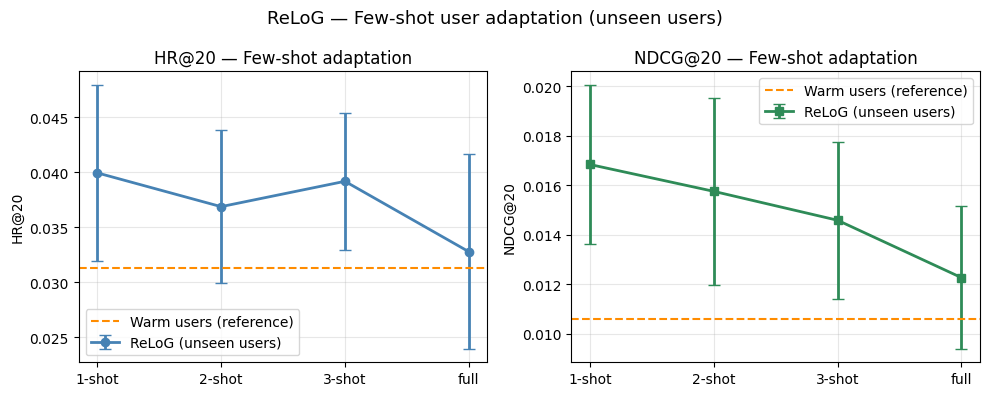

Curva salvata in fewshot_curve.pdf e fewshot_curve.png


In [38]:
# =============================================================================
# CURVA FEW-SHOT — HR@K e NDCG@K al variare degli shot
# =============================================================================
import matplotlib.pyplot as plt
 
x_labels = shot_labels  # ["1-shot", "2-shot", "3-shot", "full"]
x_pos    = np.arange(len(x_labels))
 
hr_means   = [np.mean(fewshot_hrs[l])   for l in shot_labels]
hr_stds    = [np.std(fewshot_hrs[l])    for l in shot_labels]
ndcg_means = [np.mean(fewshot_ndcgs[l]) for l in shot_labels]
ndcg_stds  = [np.std(fewshot_ndcgs[l]) for l in shot_labels]
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
 
# HR@K
ax1.errorbar(x_pos, hr_means, yerr=hr_stds, marker='o', capsize=4,
             linewidth=2, color='steelblue', label='ReLoG (unseen users)')
ax1.axhline(np.mean(warm_hrs), linestyle='--', color='darkorange',
            linewidth=1.5, label='Warm users (reference)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels)
ax1.set_ylabel(f"HR@{K}")
ax1.set_title(f"HR@{K} — Few-shot adaptation")
ax1.legend()
ax1.grid(True, alpha=0.3)
 
# NDCG@K
ax2.errorbar(x_pos, ndcg_means, yerr=ndcg_stds, marker='s', capsize=4,
             linewidth=2, color='seagreen', label='ReLoG (unseen users)')
ax2.axhline(np.mean(warm_ndcgs), linestyle='--', color='darkorange',
            linewidth=1.5, label='Warm users (reference)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels)
ax2.set_ylabel(f"NDCG@{K}")
ax2.set_title(f"NDCG@{K} — Few-shot adaptation")
ax2.legend()
ax2.grid(True, alpha=0.3)
 
plt.suptitle("ReLoG — Few-shot user adaptation (unseen users)", fontsize=13)
plt.tight_layout()
plt.savefig("fewshot_curve.pdf", bbox_inches='tight')  # per il paper
plt.savefig("fewshot_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Curva salvata in fewshot_curve.pdf e fewshot_curve.png")